In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nankundal/raw-patent-data/g_inventor_disambiguated.tsv
/kaggle/input/datasets/nankundal/raw-patent-data/g_persistent_assignee.tsv
/kaggle/input/datasets/nankundal/raw-patent-data/g_patent.tsv
/kaggle/input/datasets/nankundal/raw-patent-data/g_patent_abstract.tsv
/kaggle/input/datasets/nankundal/raw-patent-data/g_ipc_at_issue.tsv
/kaggle/input/datasets/nankundal/raw-patent-data/g_cpc_title.tsv
/kaggle/input/datasets/nankundal/raw-patent-data/g_location_disambiguated.tsv
/kaggle/input/datasets/nankundal/raw-patent-data/g_persistent_inventor.tsv


In [2]:
import pandas as pd
import sqlite3
import json
import matplotlib.pyplot as plt


In [3]:
import os
print(os.listdir('/kaggle/input'))


['datasets']


In [4]:
import os
print(os.listdir('/kaggle/input/datasets'))


['nankundal']


In [5]:
import os
print(os.listdir('/kaggle/input/datasets/nankundal'))


['raw-patent-data']


In [6]:
import os
print(os.listdir('/kaggle/input/datasets/nankundal/raw-patent-data'))


['g_inventor_disambiguated.tsv', 'g_persistent_assignee.tsv', 'g_patent.tsv', 'g_patent_abstract.tsv', 'g_ipc_at_issue.tsv', 'g_cpc_title.tsv', 'g_location_disambiguated.tsv', 'g_persistent_inventor.tsv']


In [7]:
import pandas as pd

patents = pd.read_csv('/kaggle/input/datasets/nankundal/raw-patent-data/g_patent.tsv', sep='\t', nrows=100000)

inventors = pd.read_csv('/kaggle/input/datasets/nankundal/raw-patent-data/g_inventor_disambiguated.tsv', sep='\t', nrows=100000)

assignees = pd.read_csv('/kaggle/input/datasets/nankundal/raw-patent-data/g_persistent_assignee.tsv', sep='\t', nrows=100000)



In [8]:
print(patents.head())
print(inventors.head())
print(assignees.head())


   patent_id patent_type patent_date  \
0   10000000     utility  2018-06-19   
1   10000001     utility  2018-06-19   
2   10000002     utility  2018-06-19   
3   10000003     utility  2018-06-19   
4   10000004     utility  2018-06-19   

                                        patent_title wipo_kind  num_claims  \
0  Coherent LADAR using intra-pixel quadrature de...        B2          20   
1  Injection molding machine and mold thickness c...        B2          12   
2  Method for manufacturing polymer film and co-e...        B2           9   
3  Method for producing a container from a thermo...        B2          18   
4  Process of obtaining a double-oriented film, c...        B2           6   

   withdrawn       filename  
0          0  ipg180619.xml  
1          0  ipg180619.xml  
2          0  ipg180619.xml  
3          0  ipg180619.xml  
4          0  ipg180619.xml  
  patent_id  inventor_sequence           inventor_id  \
0  D1006496                  0    fl:we_ln:jiang-165  

In [9]:
patents.columns
inventors.columns
assignees.columns


Index(['patent_id', 'assignee_sequence', 'disamb_assignee_id_20181127',
       'disamb_assignee_id_20190312', 'disamb_assignee_id_20190820',
       'disamb_assignee_id_20191008', 'disamb_assignee_id_20191231',
       'disamb_assignee_id_20200331', 'disamb_assignee_id_20200630',
       'disamb_assignee_id_20200929', 'disamb_assignee_id_20201229',
       'disamb_assignee_id_20210330', 'disamb_assignee_id_20210629',
       'disamb_assignee_id_20210930', 'disamb_assignee_id_20211230',
       'disamb_assignee_id_20220630', 'disamb_assignee_id_20220929',
       'disamb_assignee_id_20230330', 'disamb_assignee_id_20230629',
       'disamb_assignee_id_20230930', 'disamb_assignee_id_20231231',
       'disamb_assignee_id_20240331', 'disamb_assignee_id_20240630',
       'disamb_assignee_id_20240930', 'disamb_assignee_id_20241231',
       'disamb_assignee_id_20250331', 'disamb_assignee_id_20250630',
       'disamb_assignee_id_20250930', 'disamb_assignee_id_20251231'],
      dtype='object')

In [10]:
patents_clean = patents[['patent_id','patent_title','patent_date']].copy()

patents_clean.columns = ['patent_id','title','filing_date']

patents_clean['filing_date'] = pd.to_datetime(patents_clean['filing_date'])

patents_clean['year'] = patents_clean['filing_date'].dt.year

patents_clean.head()


,patent_id,title,filing_date,year
0,10000000,Coherent LADAR using intra-pixel quadrature de...,2018-06-19,2018
1,10000001,Injection molding machine and mold thickness c...,2018-06-19,2018
2,10000002,Method for manufacturing polymer film and co-e...,2018-06-19,2018
3,10000003,Method for producing a container from a thermo...,2018-06-19,2018
4,10000004,"Process of obtaining a double-oriented film, c...",2018-06-19,2018


In [11]:
inventors_clean = inventors[[
    'inventor_id',
    'disambig_inventor_name_first',
    'disambig_inventor_name_last'
]].copy()

inventors_clean['name'] = (
    inventors_clean['disambig_inventor_name_first'].fillna('') + ' ' +
    inventors_clean['disambig_inventor_name_last'].fillna('')
)

inventors_clean = inventors_clean[['inventor_id','name']]

inventors_clean.head()


,inventor_id,name
0,fl:we_ln:jiang-165,Wenjing Jiang
1,fl:ei_ln:baumker-1,Eiko BÄUMKER
2,fl:ri_ln:kroeger-1,Richard Kroeger
3,fl:th_ln:bush-1,Thomas A. Bush
4,fl:ma_ln:boudreaux-4,Matthew F. Boudreaux


In [12]:
locations = pd.read_csv('/kaggle/input/datasets/nankundal/raw-patent-data/g_location_disambiguated.tsv', sep='\t', nrows=100000)
locations.head()


,location_id,disambig_city,disambig_state,disambig_country,latitude,longitude,county,state_fips,county_fips
0,00235947-16c8-11ed-9b5f-1234bde3cd05,Westfield,PA,US,41.919237,-77.538874,Tioga,42.0,117.0
1,00236a27-16c8-11ed-9b5f-1234bde3cd05,Helfenstein,PA,US,40.750499,-76.447334,Schuylkill County,42.0,107.0
2,00236f47-16c8-11ed-9b5f-1234bde3cd05,Pine Forge,PA,US,40.281920,-75.692236,Berks County,42.0,11.0
3,00237418-16c8-11ed-9b5f-1234bde3cd05,Partlow,VA,US,38.038748,-77.638876,Spotsylvania County,51.0,177.0
4,002378d7-16c8-11ed-9b5f-1234bde3cd05,Stumpy Point,NC,US,35.698506,-75.740453,Dare,37.0,55.0


In [13]:
companies_clean = assignees[['patent_id','disamb_assignee_id_20251231']].copy()

companies_clean.columns = ['patent_id','company_id']

companies_clean.head()


,patent_id,company_id
0,4488683,a9d256f6-26f6-4553-a8ae-1a1bf4de1030
1,11872626,3ffdc6b4-9949-4395-9aae-f90cb3a18637
2,5856666,bdcc4e9e-662e-4d11-bc1a-7beddcb4e431
3,12262910,NaN
4,5204210,4840cedc-7dcd-4aa9-9d62-ee877f7ef128


In [14]:
relationships = inventors[['patent_id','inventor_id']].copy()

relationships = relationships.merge(
    companies_clean,
    on='patent_id',
    how='left'
)

relationships.head()


,patent_id,inventor_id,company_id
0,D1006496,fl:we_ln:jiang-165,NaN
1,12029253,fl:ei_ln:baumker-1,NaN
2,6584128,fl:ri_ln:kroeger-1,NaN
3,4789863,fl:th_ln:bush-1,NaN
4,11161990,fl:ma_ln:boudreaux-4,NaN


In [15]:
patents_clean.to_csv("clean_patents.csv", index=False)
inventors_clean.to_csv("clean_inventors.csv", index=False)
companies_clean.to_csv("clean_companies.csv", index=False)
relationships.to_csv("relationships.csv", index=False)


In [16]:
import sqlite3


In [17]:
import os

if os.path.exists("patents.db"):
    os.remove("patents.db")


In [18]:
import sqlite3

conn = sqlite3.connect("patents.db")


In [19]:
patents_clean.to_sql("patents", conn, if_exists="replace", index=False)
inventors_clean.to_sql("inventors", conn, if_exists="replace", index=False)
companies_clean.to_sql("companies", conn, if_exists="replace", index=False)
relationships.to_sql("relationships", conn, if_exists="replace", index=False)


100002

In [46]:
query = """
SELECT i.name, COUNT(*) total_patents
FROM relationships r
JOIN inventors i
ON r.inventor_id = i.inventor_id
GROUP BY i.name
ORDER BY total_patents DESC
LIMIT 10
"""

pd.read_sql(query, conn)


,name,total_patents
0,Shunpei Yamazaki,4624
1,Kia Silverbrook,2209
2,Tao Luo,1089
3,Jonathan P. Ive,1024
4,Richard P. Howarth,729
5,Kangguo Cheng,729
6,Duncan Robert Kerr,625
7,Bartley K. Andre,625
8,Wanshi Chen,529
9,Daniele De Iuliis,442


In [21]:

import numpy as np

In [22]:
patents = pd.read_csv(f"/kaggle/input/datasets/nankundal/raw-patent-data/g_patent.tsv", sep="\t", nrows=200000)
inventors = pd.read_csv(f"/kaggle/input/datasets/nankundal/raw-patent-data/g_inventor_disambiguated.tsv", sep="\t", nrows=200000)
assignees = pd.read_csv(f"/kaggle/input/datasets/nankundal/raw-patent-data/g_persistent_assignee.tsv", sep="\t", nrows=200000)
locations = pd.read_csv(f"/kaggle/input/datasets/nankundal/raw-patent-data/g_location_disambiguated.tsv", sep="\t", nrows=200000)
print("Data Loaded Successfully")

Data Loaded Successfully


In [23]:
patents_clean = patents[['patent_id','patent_title','patent_date']].copy()

patents_clean.columns = ['patent_id','title','filing_date']

patents_clean['filing_date'] = pd.to_datetime(patents_clean['filing_date'], errors='coerce')
patents_clean['year'] = patents_clean['filing_date'].dt.year

patents_clean.dropna(inplace=True)

patents_clean.head()


,patent_id,title,filing_date,year
0,10000000,Coherent LADAR using intra-pixel quadrature de...,2018-06-19,2018
1,10000001,Injection molding machine and mold thickness c...,2018-06-19,2018
2,10000002,Method for manufacturing polymer film and co-e...,2018-06-19,2018
3,10000003,Method for producing a container from a thermo...,2018-06-19,2018
4,10000004,"Process of obtaining a double-oriented film, c...",2018-06-19,2018


In [24]:
inventors_clean = inventors[[
    'patent_id',
    'inventor_id',
    'disambig_inventor_name_first',
    'disambig_inventor_name_last',
    'location_id'
]].copy()

inventors_clean['name'] = (
    inventors_clean['disambig_inventor_name_first'].fillna('') + " " +
    inventors_clean['disambig_inventor_name_last'].fillna('')
)

inventors_clean = inventors_clean[['patent_id','inventor_id','name','location_id']]

inventors_clean.head()


,patent_id,inventor_id,name,location_id
0,D1006496,fl:we_ln:jiang-165,Wenjing Jiang,9d072d42-49af-11ed-9879-1234bde3cd05
1,12029253,fl:ei_ln:baumker-1,Eiko BÄUMKER,67149e17-49af-11ed-9879-1234bde3cd05
2,6584128,fl:ri_ln:kroeger-1,Richard Kroeger,NaN
3,4789863,fl:th_ln:bush-1,Thomas A. Bush,NaN
4,11161990,fl:ma_ln:boudreaux-4,Matthew F. Boudreaux,04726932-16c8-11ed-9b5f-1234bde3cd05


In [25]:
assignees_clean = assignees[[
    'patent_id',
    'assignee_sequence',
    'disamb_assignee_id_20251231'
]].copy()

assignees_clean.columns = ['patent_id','sequence','company_id']

assignees_clean.head()


,patent_id,sequence,company_id
0,4488683,0,a9d256f6-26f6-4553-a8ae-1a1bf4de1030
1,11872626,0,3ffdc6b4-9949-4395-9aae-f90cb3a18637
2,5856666,0,bdcc4e9e-662e-4d11-bc1a-7beddcb4e431
3,12262910,0,NaN
4,5204210,0,4840cedc-7dcd-4aa9-9d62-ee877f7ef128


In [26]:
import pandas as pd

BASE_PATH = "/kaggle/input/datasets/nankundal/raw-patent-data"

locations = pd.read_csv(
    f"{BASE_PATH}/g_location_disambiguated.tsv",
    sep="\t",
    nrows=100000
)

print(locations.head())


                            location_id disambig_city disambig_state  \
0  00235947-16c8-11ed-9b5f-1234bde3cd05     Westfield             PA   
1  00236a27-16c8-11ed-9b5f-1234bde3cd05   Helfenstein             PA   
2  00236f47-16c8-11ed-9b5f-1234bde3cd05    Pine Forge             PA   
3  00237418-16c8-11ed-9b5f-1234bde3cd05       Partlow             VA   
4  002378d7-16c8-11ed-9b5f-1234bde3cd05  Stumpy Point             NC   

  disambig_country   latitude  longitude               county  state_fips  \
0               US  41.919237 -77.538874                Tioga        42.0   
1               US  40.750499 -76.447334    Schuylkill County        42.0   
2               US  40.281920 -75.692236         Berks County        42.0   
3               US  38.038748 -77.638876  Spotsylvania County        51.0   
4               US  35.698506 -75.740453                 Dare        37.0   

   county_fips  
0        117.0  
1        107.0  
2         11.0  
3        177.0  
4         55.0  


In [27]:
print(locations.columns.tolist())


['location_id', 'disambig_city', 'disambig_state', 'disambig_country', 'latitude', 'longitude', 'county', 'state_fips', 'county_fips']


In [28]:
locations_clean = locations[['location_id', 'disambig_country']].copy()

locations_clean.columns = ['location_id', 'country']

locations_clean.head()


,location_id,country
0,00235947-16c8-11ed-9b5f-1234bde3cd05,US
1,00236a27-16c8-11ed-9b5f-1234bde3cd05,US
2,00236f47-16c8-11ed-9b5f-1234bde3cd05,US
3,00237418-16c8-11ed-9b5f-1234bde3cd05,US
4,002378d7-16c8-11ed-9b5f-1234bde3cd05,US


In [29]:
inventors_clean = inventors_clean.merge(
    locations_clean,
    on='location_id',
    how='left'
)

inventors_clean.head()


,patent_id,inventor_id,name,location_id,country
0,D1006496,fl:we_ln:jiang-165,Wenjing Jiang,9d072d42-49af-11ed-9879-1234bde3cd05,CN
1,12029253,fl:ei_ln:baumker-1,Eiko BÄUMKER,67149e17-49af-11ed-9879-1234bde3cd05,DE
2,6584128,fl:ri_ln:kroeger-1,Richard Kroeger,NaN,NaN
3,4789863,fl:th_ln:bush-1,Thomas A. Bush,NaN,NaN
4,11161990,fl:ma_ln:boudreaux-4,Matthew F. Boudreaux,04726932-16c8-11ed-9b5f-1234bde3cd05,US


In [30]:
relationships = inventors_clean.merge(
    assignees_clean,
    on='patent_id',
    how='left'
)

relationships.head()


,patent_id,inventor_id,name,location_id,country,sequence,company_id
0,D1006496,fl:we_ln:jiang-165,Wenjing Jiang,9d072d42-49af-11ed-9879-1234bde3cd05,CN,NaN,NaN
1,12029253,fl:ei_ln:baumker-1,Eiko BÄUMKER,67149e17-49af-11ed-9879-1234bde3cd05,DE,NaN,NaN
2,6584128,fl:ri_ln:kroeger-1,Richard Kroeger,NaN,NaN,NaN,NaN
3,4789863,fl:th_ln:bush-1,Thomas A. Bush,NaN,NaN,NaN,NaN
4,11161990,fl:ma_ln:boudreaux-4,Matthew F. Boudreaux,04726932-16c8-11ed-9b5f-1234bde3cd05,US,NaN,NaN


In [44]:
patents_clean.to_csv("clean_patents.csv", index=False)
inventors_clean.to_csv("clean_inventors.csv", index=False)
assignees_clean.to_csv("clean_companies.csv", index=False)
relationships.to_csv("relationships.csv", index=False)


In [45]:
conn = sqlite3.connect("patents.db")

patents_clean.to_sql("patents", conn, if_exists="replace", index=False)
inventors_clean.to_sql("inventors", conn, if_exists="replace", index=False)
assignees_clean.to_sql("companies", conn, if_exists="replace", index=False)
relationships.to_sql("relationships", conn, if_exists="replace", index=False)

print("Database Created")


Database Created


In [33]:
query = """
SELECT name, COUNT(*) AS total_patents
FROM inventors
GROUP BY name
ORDER BY total_patents DESC
LIMIT 10
"""
top_inventors = pd.read_sql(query, conn)
top_inventors


,name,total_patents
0,Shunpei Yamazaki,68
1,Kia Silverbrook,47
2,Tao Luo,33
3,Jonathan P. Ive,32
4,Richard P. Howarth,27
5,Kangguo Cheng,27
6,Li Zhang,25
7,Duncan Robert Kerr,25
8,Bartley K. Andre,25
9,Wanshi Chen,23


In [34]:
Top companies

SyntaxError: invalid syntax (2943628966.py, line 1)

In [41]:
query = """
SELECT company_id, COUNT(*) AS total_patents
FROM companies
GROUP BY company_id
ORDER BY total_patents DESC
LIMIT 10
"""
top_companies = pd.read_sql(query, conn)
top_companies


,company_id,total_patents
0,533e0469-baac-46b7-9576-669db08092eb,4036
1,29b8f534-149e-443c-b76b-3c4a222da89c,3647
2,dfdf1f1a-8f22-41dc-a7f0-855bde20ca67,2081
3,55bc7465-2823-418d-9835-41d555c610a6,1460
4,5952964e-63c6-4284-9012-0fdd0643f715,1276
5,4ef2b9c8-d3e7-40d6-ac53-8694d8fe890f,1208
6,55715b8e-9037-47c9-8e27-a2acf13d6047,1145
7,b904f566-62d6-44a5-8689-7b5c5a3a1a19,1122
8,93f8c962-7a18-45c0-b192-7a141f9a8b6c,1106
9,906da649-dd98-4eac-a78c-d5dc3cc385b1,1099


In [ ]:
countries via locations

In [42]:
locations_clean.to_sql("locations", conn, if_exists="replace", index=False)


100000

In [43]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)


,name
0,patents
1,inventors
2,companies
3,relationships
4,locations


In [47]:
pd.read_sql("PRAGMA table_info(locations);", conn)


,cid,name,type,notnull,dflt_value,pk
0,0,location_id,TEXT,0,None,0
1,1,country,TEXT,0,None,0


In [48]:
query = """
SELECT l.country, COUNT(*) AS total
FROM inventors i
JOIN locations l
ON i.location_id = l.location_id
GROUP BY l.country
ORDER BY total DESC
LIMIT 10
"""

top_countries = pd.read_sql(query, conn)
top_countries


,country,total
0,US,95892
1,JP,33465
2,DE,11653
3,KR,10600
4,CN,8708
5,TW,5487
6,GB,4166
7,FR,4111
8,CA,3881
9,IN,2156


In [ ]:
trands over time

In [49]:
query = """
SELECT year, COUNT(*) AS patents
FROM patents
GROUP BY year
ORDER BY year
"""
trend = pd.read_sql(query, conn)
trend


,year,patents
0,2018,164524
1,2019,35476


In [ ]:
joint query

In [50]:
query = """
SELECT p.title, i.name, c.company_id
FROM patents p
JOIN relationships r ON p.patent_id = r.patent_id
JOIN inventors i ON r.inventor_id = i.inventor_id
JOIN companies c ON r.patent_id = c.patent_id
LIMIT 20
"""
pd.read_sql(query, conn)


,title,name,company_id
0,Optical fiber cable connector,Christopher Gaal,e80f4f96-7882-4c7e-b523-502d8623cb99
1,Electromagnetic interference shielding apparatus,Huasheng Zhao,7f7f1d2f-d858-4e97-8723-87f06ac28989
2,Cutting insert and indexable drill,Hyo Joon Lim,361ffb07-0c17-47f5-a6e6-2018ada787c0
3,CEM switching device,Lucian Shifren,c0dd0b4d-fbbe-4965-b458-304bb690d1e8
4,Semiconductor device and manufacturing method ...,Shinichi Watanuki,f354228e-3553-4520-9ba7-adc273a6e7ad
5,Manufacturing methods of decorative laminates ...,Patrick Van den Bergen,3bc703fa-e029-40a7-8355-e53c1eda41b6
6,Card body for a data carrier and inlay for a p...,Stefan Kluge,a7755298-56ae-4d0b-a19a-ea0cb55b787c
7,"Compounds, compositions and methods",Jianwen A. Feng,7757a63f-afcb-4b32-8398-8560b865ca91
8,Methods and systems to separate seismic data a...,Nils Lunde,ce20d9b7-e190-4934-b997-2a79f1c7db43
9,Optoelectronic circuit having light-emitting d...,Frédéric Mercier,d04b6616-9e70-4f3b-ba75-0a3c3f09bd6d


In [ ]:
CTE Query

In [51]:
query = """
WITH yearly AS (
    SELECT year, COUNT(*) AS total
    FROM patents
    GROUP BY year
)
SELECT * FROM yearly
WHERE total > 1000
ORDER BY year
"""
pd.read_sql(query, conn)


,year,total
0,2018,164524
1,2019,35476


In [52]:
query = """
SELECT name,
COUNT(*) AS total_patents,
RANK() OVER(ORDER BY COUNT(*) DESC) AS rank
FROM inventors
GROUP BY name
LIMIT 10
"""
pd.read_sql(query, conn)


,name,total_patents,rank
0,Shunpei Yamazaki,68,1
1,Kia Silverbrook,47,2
2,Tao Luo,33,3
3,Jonathan P. Ive,32,4
4,Richard P. Howarth,27,5
5,Kangguo Cheng,27,5
6,Li Zhang,25,7
7,Duncan Robert Kerr,25,7
8,Bartley K. Andre,25,7
9,Wanshi Chen,23,10


In [ ]:
Export Report Queries

In [53]:
top_inventors.to_csv("top_inventors.csv", index=False)
top_companies.to_csv("top_companies.csv", index=False)
top_countries.to_csv("top_countries.csv", index=False)
trend.to_csv("country_trends.csv", index=False)


In [ ]:
//Json report

In [54]:
report = {
    "total_patents": len(patents_clean),
    "top_inventors": top_inventors.to_dict(orient="records"),
    "top_companies": top_companies.to_dict(orient="records"),
    "top_countries": top_countries.to_dict(orient="records"),
    "yearly_trends": trend.to_dict(orient="records")
}

with open("report.json", "w") as f:
    json.dump(report, f, indent=4)

print("JSON Report Created")


JSON Report Created


In [ ]:
Visualisations

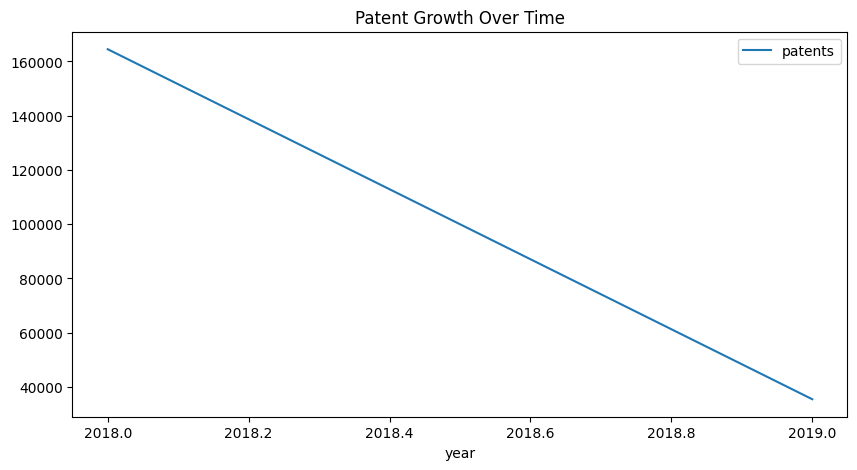

In [55]:
trend.plot(x='year', y='patents', figsize=(10,5))
plt.title("Patent Growth Over Time")
plt.show()


In [ ]:
Built an end-to-end patent intelligence pipeline using Python, Pandas, SQLite, and SQL over 200k+ USPTO records, generating analytical reports and trend dashboards.


In [56]:
import pandas as pd

BASE_PATH = "/kaggle/input/datasets/nankundal/raw-patent-data"

patents = pd.read_csv(
    f"{BASE_PATH}/g_patent.tsv",
    sep="\t",
    usecols=['patent_id','patent_title','patent_date'],
    nrows=100000
)

inventors = pd.read_csv(
    f"{BASE_PATH}/g_inventor_disambiguated.tsv",
    sep="\t",
    usecols=[
        'patent_id','inventor_id',
        'disambig_inventor_name_first',
        'disambig_inventor_name_last',
        'location_id'
    ],
    nrows=100000
)


In [ ]:
!pip install streamlit --quiet


In [60]:
import streamlit as st
print("Streamlit installed successfully")


Streamlit installed successfully


In [59]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 82.5 MB/s eta 0:00:00:00:010:01


In [62]:
query = """
SELECT year, COUNT(*) AS patents
FROM patents
GROUP BY year
ORDER BY year
"""

trend = pd.read_sql(query, conn)
trend.to_csv("country_trends.csv", index=False)

trend.head()


,year,patents
0,2018,164524
1,2019,35476


In [65]:
query = """
SELECT name, COUNT(*) AS patents
FROM inventors
GROUP BY name
ORDER BY patents DESC
LIMIT 10
"""

top_inventors = pd.read_sql(query, conn)
top_inventors.to_csv("top_inventors.csv", index=False)


In [66]:
query = """
SELECT company_id, COUNT(*) AS patents
FROM companies
GROUP BY company_id
ORDER BY patents DESC
LIMIT 10
"""

top_companies = pd.read_sql(query, conn)
top_companies.to_csv("top_companies.csv", index=False)


In [67]:
import os
print(os.listdir())


['clean_patents.csv', 'report.json', 'clean_companies.csv', 'patents.db', 'top_companies.csv', 'relationships.csv', 'top_inventors.csv', 'top_countries.csv', 'clean_inventors.csv', 'country_trends.csv', '.virtual_documents']


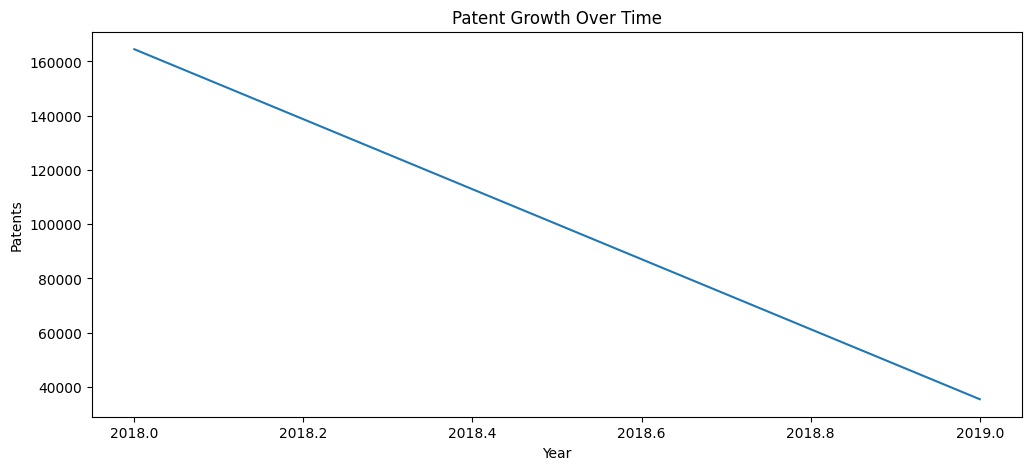

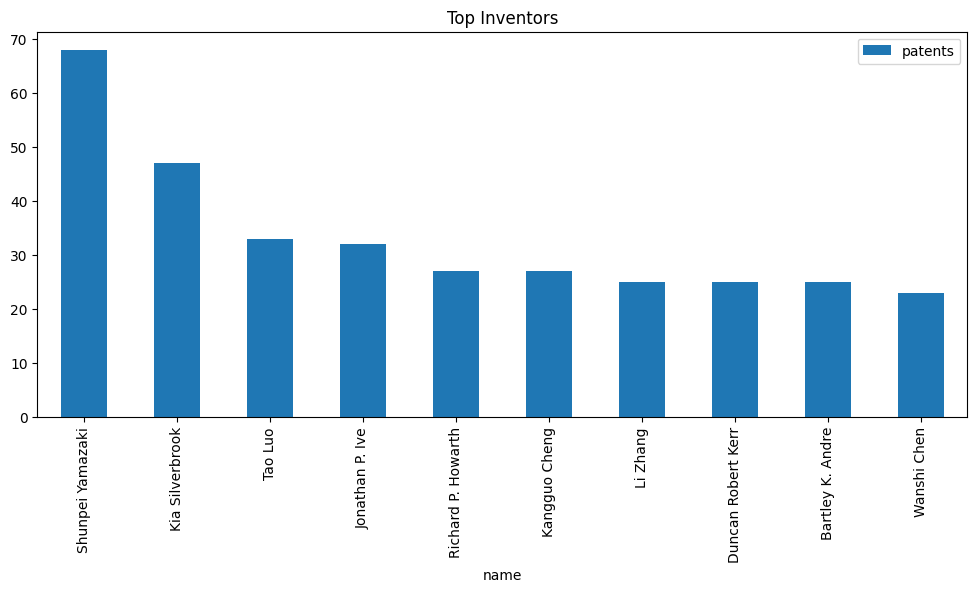

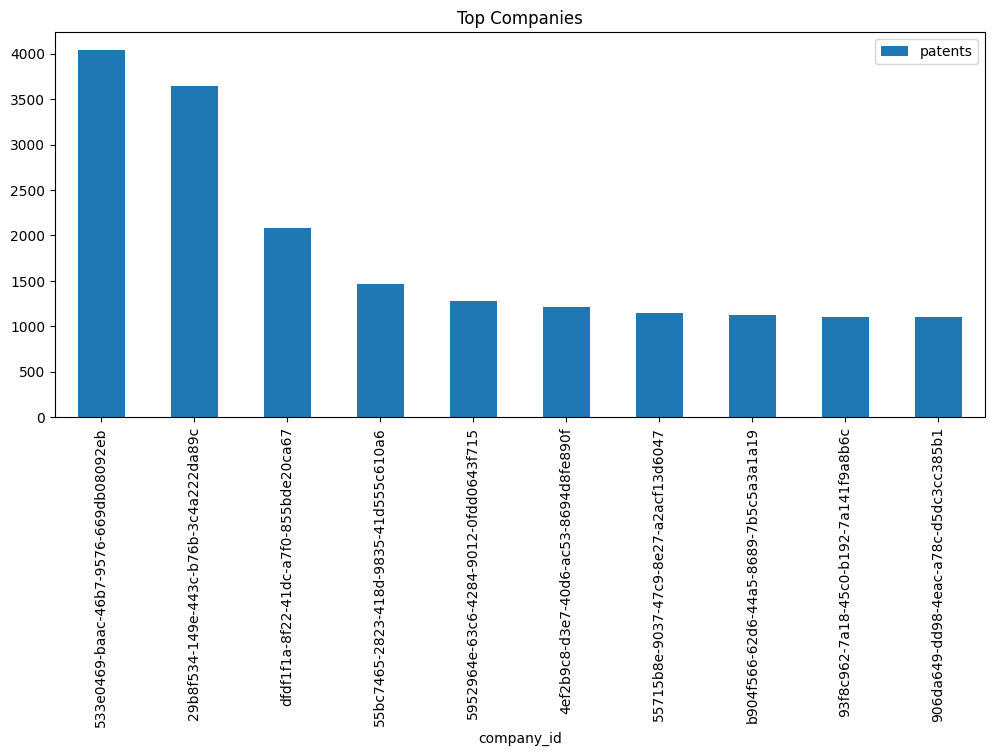

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

trend = pd.read_csv("country_trends.csv")
inventors = pd.read_csv("top_inventors.csv")
companies = pd.read_csv("top_companies.csv")

# Patent Trend
plt.figure(figsize=(12,5))
plt.plot(trend["year"], trend["patents"])
plt.title("Patent Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Patents")
plt.show()

# Top Inventors
inventors.plot(kind='bar', x='name', y='patents', figsize=(12,5), title="Top Inventors")
plt.show()

# Top Companies
companies.plot(kind='bar', x='company_id', y='patents', figsize=(12,5), title="Top Companies")
plt.show()


In [69]:
import streamlit as st
import pandas as pd

# Page settings
st.set_page_config(
    page_title="Global Patent Intelligence Dashboard",
    layout="wide"
)

# Title
st.title("🌍 Global Patent Intelligence Dashboard")
st.markdown("Analyze patent trends, inventors, companies, and countries.")

# Load data
trend = pd.read_csv("country_trends.csv")
inventors = pd.read_csv("top_inventors.csv")
companies = pd.read_csv("top_companies.csv")

# Metrics row
col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Years Covered", trend["year"].nunique())

with col2:
    st.metric("Top Inventors", len(inventors))

with col3:
    st.metric("Top Companies", len(companies))

st.divider()

# Patent trend chart
st.subheader("📈 Patent Growth Over Time")
st.line_chart(trend.set_index("year"))

# Top inventors
st.subheader("🏆 Top Inventors")
st.bar_chart(inventors.set_index("name"))

# Top companies
st.subheader("🏢 Top Companies")
st.bar_chart(companies.set_index("company_id"))

# Raw data viewer
st.subheader("📄 View Raw Data")
option = st.selectbox(
    "Choose dataset",
    ["Patent Trends", "Inventors", "Companies"]
)

if option == "Patent Trends":
    st.dataframe(trend)

elif option == "Inventors":
    st.dataframe(inventors)

else:
    st.dataframe(companies)

st.caption("Built using Python + Streamlit + Patent Data")



2026-04-28 05:19:24.258 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 05:19:24.262 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 05:19:24.471 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-28 05:19:24.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 05:19:24.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 05:19:24.476 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 05:19:24.476 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

In [70]:
pip install streamlit pandas plotly
streamlit run patent_dashboard_app.py


SyntaxError: invalid syntax (1249766387.py, line 1)

In [71]:
!pip install streamlit pandas plotly


In [72]:
!streamlit run patent_dashboard_app.py


Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: patent_dashboard_app.py


In [73]:
%%writefile patent_dashboard_app.py

import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px

st.set_page_config(page_title="Patent Dashboard", layout="wide")

st.title("🌍 Global Patent Intelligence Dashboard")

# Load CSV files
trend = pd.read_csv("country_trends.csv")
inventors = pd.read_csv("top_inventors.csv")
companies = pd.read_csv("top_companies.csv")

# Metrics
col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Years Covered", trend["year"].nunique())

with col2:
    st.metric("Top Inventors", len(inventors))

with col3:
    st.metric("Top Companies", len(companies))

# Trend chart
st.subheader("📈 Patent Trends")
fig = px.line(trend, x="year", y="patents")
st.plotly_chart(fig, use_container_width=True)

# Inventors
st.subheader("🏆 Top Inventors")
st.dataframe(inventors)

# Companies
st.subheader("🏢 Top Companies")
st.dataframe(companies)


Writing patent_dashboard_app.py


In [74]:
import os
print(os.listdir())


['clean_patents.csv', 'patent_dashboard_app.py', 'report.json', 'clean_companies.csv', 'patents.db', 'top_companies.csv', 'relationships.csv', 'top_inventors.csv', 'top_countries.csv', 'clean_inventors.csv', 'country_trends.csv', '.virtual_documents']


In [75]:
!streamlit run patent_dashboard_app.py





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://34.19.77.180:8501

^C
  Stopping...


In [77]:
import plotly.express as px
import pandas as pd

df = pd.read_csv("country_trends.csv")

fig = px.line(df, x="year", y="patents", title="Patent Trends")
fig.show()


In [83]:
import os
print(os.listdir())


['clean_patents.csv', 'patent_dashboard_app.py', 'report.json', 'clean_companies.csv', 'patents.db', 'top_companies.csv', 'relationships.csv', 'top_inventors.csv', 'top_countries.csv', 'clean_inventors.csv', 'country_trends.csv', '.virtual_documents']


In [84]:
import os
print(os.listdir('/kaggle/input/datasets/nankundal/raw-patent-data'))

['g_inventor_disambiguated.tsv', 'g_persistent_assignee.tsv', 'g_patent.tsv', 'g_patent_abstract.tsv', 'g_ipc_at_issue.tsv', 'g_cpc_title.tsv', 'g_location_disambiguated.tsv', 'g_persistent_inventor.tsv']


In [85]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("patents.db")


In [86]:
README.md


NameError: name 'README' is not defined